extract marker counts and morphological information from all the cells in your images

In [1]:
# import required packages
import os
import warnings
import pandas as pd
from alpineer import io_utils
from skimage import io
from ark.segmentation import marker_quantification, segmentation_utils
from ark.utils import deepcell_service_utils, example_dataset, plot_utils

## 0: Set root directory and download example dataset

Here we are using the example data located in `/data/example_dataset/input_data`. To modify this notebook to run using your own data, simply change `base_dir` to point to your own sub-directory within the data folder.

* `base_dir`: the path to all of your imaging data. This directory will contain all of the data generated by this notebook.

In [2]:
# set up the base directory
base_dir = "../../"

If you would like to test the features in Ark with an example dataset, run the cell below. It will download a dataset consisting of 11 FOVs with 22 channels. You may find more information about the example dataset in the [README](../README.md#example-dataset).

If you are using your own data, skip the cell below.

* `overwrite_existing`: If set to `False`, it will not overwrite existing data in the `data/example_dataset`. Recommended leaving as `True` if you are doing a clean run of the `ark` pipeline using this dataset from the start. If you already have the dataset downloaded, set to `False`.

## 1: set file paths and parameters

### All data, images, files, etc. must be placed in the 'data' directory, and referenced via '../data/path_to_your_data'

If you're interested in directly interfacing with Google Drive, consult the documentation [here](https://ark-analysis.readthedocs.io/en/latest/_rtd/google_docs_usage.html).

In [3]:
# set up file paths

tiff_dir = os.path.join(base_dir, "split_channels")

cell_table_dir = os.path.join(base_dir, "segmentation/cell_table")

deepcell_input_dir = os.path.join(base_dir, "segmentation/deepcell_input")

deepcell_output_dir = os.path.join(base_dir, "segmentation/deepcell_output")
deepcell_visualization_dir = os.path.join(base_dir, "segmentation/deepcell_visualization")

In [4]:
# create directories if do not exist
for directory in [cell_table_dir, deepcell_input_dir, deepcell_output_dir, deepcell_visualization_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)

In [5]:
# validate paths
io_utils.validate_paths([base_dir,
                         tiff_dir,
                         deepcell_input_dir,
                         deepcell_output_dir,
                         cell_table_dir,
                         deepcell_visualization_dir
                         ])

### Compute and filter fov paths

In [5]:
# either get all fovs in the folder...
fovs = io_utils.list_folders(tiff_dir)

# some of the images was not possible to process with Mesmer, so consider only the images that have a valid segmentation
Leap_ID_segmented = pd.read_csv( os.path.join(base_dir, 'segmentation/LeapID_segmented.csv'))
fovs = [*set(Leap_ID_segmented.Leap_ID)&set(fovs)]

In [37]:
! ls ../segmentation

cell_table	deepcell_output		LeapID_segmented.csv
deepcell_input	deepcell_visualization


### Load images into notebook, process, and save as Mesmer compatable input

In [9]:
'''
# NOTE: at least one of nucs and mems must not be None
# nuclear channel name(s) (or nucs = None)
nucs = ['DNA1','DNA2']

# membrane channel name(s) (or mems = None)
mems = ['CD14', 'CD11b', 'CD45', 'CD366', 'CD4', 'E-Cadherin',
       'HLA-DR-DQ-DP', 'CD8a', 'Beta-Catenin', 'B7-H4', 'CD3', 'CD27',
       'CD45RO', 'Vimentin']
'''

In [6]:
'''
# generate and save deepcell input tiffs
# set img_sub_folder param to None if the image files in tiff_dir are not in a separate sub folder 
deepcell_service_utils.generate_deepcell_input(
    deepcell_input_dir,
    tiff_dir,
    nucs,
    mems,
    fovs,
    img_sub_folder=None
)
'''

'\n# generate and save deepcell input tiffs\n# set img_sub_folder param to None if the image files in tiff_dir are not in a separate sub folder \ndeepcell_service_utils.generate_deepcell_input(\n    deepcell_input_dir,\n    tiff_dir,\n    nucs,\n    mems,\n    fovs,\n    img_sub_folder=None\n)\n'

### We can then save the segmented mask overlaid on the imaging data

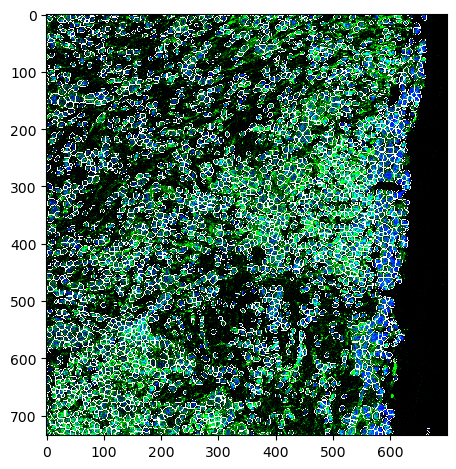

In [9]:
# display the channel overlay for a fov, useful for quick verification
warnings.simplefilter("ignore")

fov_to_display = io_utils.remove_file_extensions([fovs[0]])[0]

fov_overlay = plot_utils.create_overlay(
    fov=fov_to_display,
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    img_overlay_chans=['nuclear_channel', 'membrane_channel'],
    seg_overlay_comp='whole_cell'
)

_ = io.imshow(fov_overlay)

In [6]:
# save the overlaid segmentation labels for each fov (these will not display, but will save in viz_dir)
segmentation_utils.save_segmentation_labels(
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    output_dir=deepcell_visualization_dir,
    fovs=io_utils.remove_file_extensions(fovs),
    channels=['nuclear_channel', 'membrane_channel']
)

KeyError: "<COMPRESSION.ADOBE_DEFLATE: 8> requires the 'imagecodecs' package"

In [11]:
!ls ../../segmentation/deepcell_input/

Leap001_10.tiff    Leap014_16.tiff  Leap048_2.tiff   Leap062_9.tiff
Leap001_8.tiff	   Leap014_17.tiff  Leap048_3.tiff   Leap064_1.tiff
Leap001_9.tiff	   Leap014_18.tiff  Leap048_4.tiff   Leap064_2.tiff
Leap002_1.tiff	   Leap014_19.tiff  Leap048_5.tiff   Leap064_3.tiff
Leap002_3.tiff	   Leap014_20.tiff  Leap048_6.tiff   Leap064_4.tiff
Leap002_4.tiff	   Leap014_21.tiff  Leap048_7.tiff   Leap064_5.tiff
Leap002_5.tiff	   Leap014_22.tiff  Leap048_8.tiff   Leap064_6.tiff
Leap002_6.tiff	   Leap014_23.tiff  Leap049_1.tiff   Leap064_7.tiff
Leap002_7.tiff	   Leap014_24.tiff  Leap049_2.tiff   Leap064_8.tiff
Leap004_1.tiff	   Leap015_1.tiff   Leap049_3.tiff   Leap064_9.tiff
Leap004_10.tiff    Leap015_2.tiff   Leap051_15.tiff  Leap066_1.tiff
Leap004_14.tiff    Leap015_3.tiff   Leap051_16.tiff  Leap066_10.tiff
Leap004_15.tiff    Leap015_4.tiff   Leap051_17.tiff  Leap066_11.tiff
Leap004_16.tiff    Leap015_5.tiff   Leap051_18.tiff  Leap066_12.tiff
Leap004_17.tiff    Leap015_6.tiff   Leap051_19.tiff  L

### Afterwards, we can generate expression matrices from the labeling + imaging data

In [7]:
# set to True to add nuclear cell properties to the expression matrix
nuclear_counts = True

# set to True to bypass expensive cell property calculations
# only cell label, size, and centroid will be extracted if True
fast_extraction = False

For a full list of features extracted, please refer to the cell table section of: https://ark-analysis.readthedocs.io/en/latest/_rtd/data_types.html

In [ ]:
# now extract the segmented imaging data to create normalized and transformed expression matrices
# note that if you're loading your own dataset, please make sure all the imaging data is in the same folder
# with each fov given its own folder and all fovs having the same channels
cell_table_size_normalized, cell_table_arcsinh_transformed = \
    marker_quantification.generate_cell_table(segmentation_dir=deepcell_output_dir,
                                              tiff_dir=tiff_dir,
                                              img_sub_folder=None,
                                              fovs=fovs,
                                              batch_size=20,
                                              nuclear_counts=nuclear_counts,
                                              fast_extraction=fast_extraction)

extracting data from Leap001_10
extracting data from Leap001_8
extracting data from Leap001_9
extracting data from Leap002_1
extracting data from Leap002_3
extracting data from Leap002_4
extracting data from Leap002_5
extracting data from Leap002_6
extracting data from Leap002_7
extracting data from Leap003_11
extracting data from Leap003_12
extracting data from Leap003_13
extracting data from Leap003_14
extracting data from Leap003_15
extracting data from Leap003_16
extracting data from Leap004_1
extracting data from Leap004_10
extracting data from Leap004_2
extracting data from Leap004_2_11
extracting data from Leap004_2_12
extracting data from Leap004_2_13
extracting data from Leap004_2_14
extracting data from Leap004_2_15
extracting data from Leap004_2_16
extracting data from Leap004_3
extracting data from Leap004_4
extracting data from Leap004_5
extracting data from Leap004_6
extracting data from Leap004_7
extracting data from Leap004_8
extracting data from Leap004_9
extracting da

In [ ]:
# Set the compression level if desired, ZSTD compression can offer up to a 60-70% reduction in file size.
# NOTE: Compressed `csv` files cannot be opened in Excel. They must be uncompressed beforehand.
compression = None

# Uncomment the line below to allow for compressed `csv` files.
#compression = True#{"method": "zstd", "level": 3}

if (compression is None) or (compression ==False):
    cell_table_normalized_path = os.path.join(cell_table_dir, 'cell_table_size_normalized.csv')
    cell_table_arcsinh_path = os.path.join(cell_table_dir, 'cell_table_arcsinh_transformed.csv')
else:
    cell_table_normalized_path = os.path.join(cell_table_dir, 'cell_table_size_normalized.zstd')
    cell_table_arcsinh_path = os.path.join(cell_table_dir, 'cell_table_arcsinh_transformed.zstd')
    
    
cell_table_size_normalized.to_csv(cell_table_normalized_path,
                                   index=False)
cell_table_arcsinh_transformed.to_csv(cell_table_arcsinh_path,
                                       index=False)

In [38]:
import numpy as np
np.multiply(*cell_table_size_normalized.shape)*(8+1)/1024**3

3.649150704033673

In [ ]:
cell_table_size_normalized.dtypes

In [10]:
cell_table_normalized_path

'../../segmentation/cell_table/cell_table_size_normalized.csv'